# LDA on Clean vs Noisy Dataset — Step-by-Step Jupyter Notebook

## Objective

The objective of this experiment is to study how noise affects the performance of Linear Discriminant Analysis (LDA).

We will:

- Apply LDA on both clean and noisy datasets
- Compare their projections
- Analyze how noise impacts class separation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

In [2]:
# Load clean dataset
clean_df = pd.read_csv('lda_clean.csv')

# Load noisy dataset
noisy_df = pd.read_csv('lda_noisy.csv')

# Display first few rows
print("Clean Dataset:")
print(clean_df.head())

print("\nNoisy Dataset:")
print(noisy_df.head())

Clean Dataset:
         F1         F2        F3        F4  Label
0 -2.167442  10.890457  5.590303  1.396266      0
1 -5.850472  -6.407512 -8.582298  8.306214      1
2 -6.861193  -6.532528 -9.378087  6.545218      1
3 -7.975902  -8.320160 -7.243823  6.476562      1
4 -7.881247  -7.161210 -7.040641  7.964366      1

Noisy Dataset:
         F1         F2        F3        F4         F5         F6         F7  \
0 -2.167442  10.890457  5.590303  1.396266   7.569886  -9.221653   8.696059   
1 -5.850472  -6.407512 -8.582298  8.306214   4.134349  18.767958  -7.737892   
2 -6.861193  -6.532528 -9.378087  6.545218 -17.787202  14.960443   6.543657   
3 -7.975902  -8.320160 -7.243823  6.476562   2.799686 -11.254890  24.457520   
4 -7.881247  -7.161210 -7.040641  7.964366   1.093948   7.257666   4.810092   

          F8  Label  
0  13.556379      0  
1 -12.446547      1  
2  -0.555847      1  
3   1.292212      1  
4   2.238840      1  


In [3]:
# Clean dataset
X_clean = clean_df.iloc[:, :-1]
y_clean = clean_df.iloc[:, -1]

# Noisy dataset
X_noisy = noisy_df.iloc[:, :-1]
y_noisy = noisy_df.iloc[:, -1]

print("Clean Features Shape:", X_clean.shape)
print("Noisy Features Shape:", X_noisy.shape)

Clean Features Shape: (300, 4)
Noisy Features Shape: (300, 8)


In [6]:
# Standardize clean dataset
scaler_clean = StandardScaler()
X_clean_scaled = scaler_clean.fit_transform(X_clean)

# Standardize noisy dataset
scaler_noisy = StandardScaler()
X_noisy_scaled = scaler_noisy.fit_transform(X_noisy)

In [7]:
# Apply LDA on clean dataset
lda_clean = LinearDiscriminantAnalysis(n_components=1)

X_clean_lda = lda_clean.fit_transform(X_clean_scaled, y_clean)

print("Clean Dataset LDA Shape:", X_clean_lda.shape)

Clean Dataset LDA Shape: (300, 1)


In [8]:
# Apply LDA on noisy dataset
lda_noisy = LinearDiscriminantAnalysis(n_components=1)

X_noisy_lda = lda_noisy.fit_transform(X_noisy_scaled, y_noisy)

print("Noisy Dataset LDA Shape:", X_noisy_lda.shape)

Noisy Dataset LDA Shape: (300, 1)


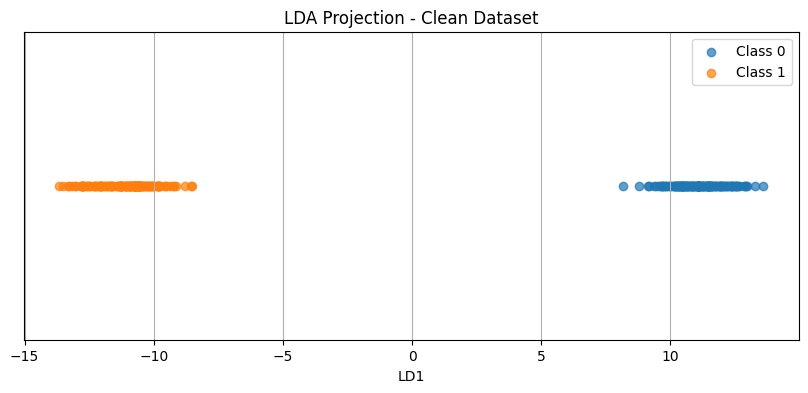

In [16]:
# Plot LDA projection for clean dataset
plt.figure(figsize=(10, 4))

for cls in np.unique(y_clean):
    plt.scatter(
        X_clean_lda[y_clean == cls],
        np.zeros(sum(y_clean == cls)),
        label=f'Class {cls}',
        alpha=0.7
    )

plt.title('LDA Projection - Clean Dataset')
plt.xlabel('LD1')
plt.yticks([])
plt.legend()
plt.grid(True)
plt.show()

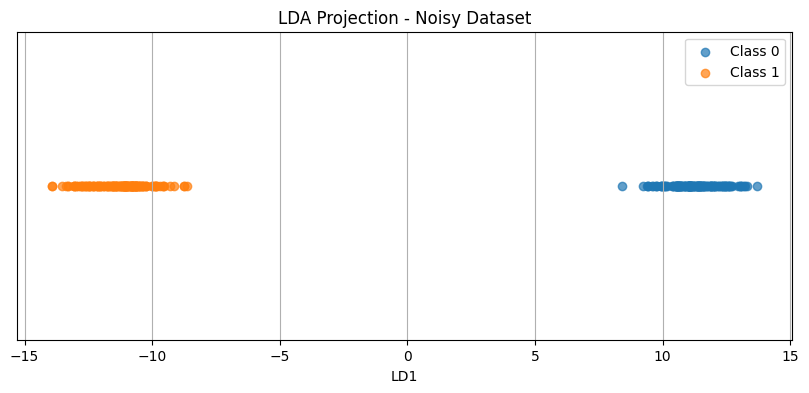

In [10]:
# Plot LDA projection for noisy dataset
plt.figure(figsize=(10, 4))

for cls in np.unique(y_noisy):
    plt.scatter(
        X_noisy_lda[y_noisy == cls],
        np.zeros(sum(y_noisy == cls)),
        label=f'Class {cls}',
        alpha=0.7
    )

plt.title('LDA Projection - Noisy Dataset')
plt.xlabel('LD1')
plt.yticks([])
plt.legend()
plt.grid(True)
plt.show()

## Questions and Answers

### 1. Which dataset shows clearer separation?

The clean dataset shows clearer separation with minimal overlap between classes.

### 2. How does noise affect LDA performance?

Noise increases within-class variance and reduces class separability, making LDA less effective.

### 3. Do irrelevant features influence LDA direction?

Yes. Irrelevant or noisy features can distort the discriminant direction because LDA uses all input features.

### 4. What does this imply for real-world data?

Real-world datasets require preprocessing such as feature selection, noise reduction, and data cleaning before applying LDA.


## Final Conclusion

This experiment demonstrates that LDA is sensitive to noisy and irrelevant features.

- Clean datasets provide better separation.
- Noisy datasets reduce discriminative performance.
- Proper preprocessing is essential for reliable LDA results.
